##### ***Bahdanau注意力***
###### 在先前的encoder-decoder架构中，RNN编码器将长度可变的序列转化为固定形状的上下文变量c，然后利用这个c来进行解码生成输出，这样的弊端在于上下文变量c是固定的，也就是说其实输入序列中的词元并非每一个都是对当前预测有用的，而固定的c会导致所有的预测都强制的将输入的信息混杂一起，做不到聚焦于当前预测最相关的输入。所以有没有一种办法可以改变上下文变量，让它能选择性的利用输入信息。<br>在Graves的为给定文本序列生成手写的挑战中，他设计了一种可微注意力模型，让文本字符与字迹单向对齐，受此启发，Bahdanau等人提出了一个没有严格单向限制的可微注意力模型，让模型将注意力自主的集中在最相关的几个输入中，而这样一来原先的上下文变量c就可以使用注意力集中的输出来实现了。
##### ***Bahdanau注意力模型***
###### 假设输入序列中有T个词元，解码时间步$t'$的上下文变量是注意力集中的输出：
$$c_{t'} = \sum_{t=1}^T\alpha(s_{t'-1}, h_t)h_t$$
###### 其中，时间步$t'-1$时的解码器隐状态$s_{t'-1}是查询$，编码器隐状态$h_t$既是键也是值，注意力权重$\alpha$是使用加性注意力打分函数计算的。具体架构如下：
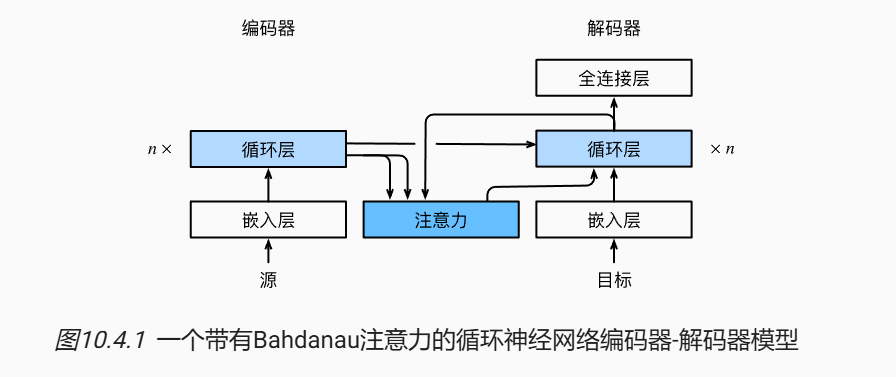


In [4]:
import torch
from torch import nn
from d2l import torch as d2l

###### 关于Bahdanau注意力的代码实现，其实我们只需要重新定义解码器即可，让解码器在每个时间步都使用Bahdanau注意力来计算上下文变量c。

In [5]:
class AttentionDecoder(nn.Module):
    def __init__(self, **kwargs):
        super(AttentionDecoder, self).__init__(**kwargs)
    
    @property
    def attention_weights(self):
        raise NotImplementedError

###### 首先初始化解码器的状态，需要编码器在所有时间步的最终层隐状态，将作为注意力的键和值；上一时间步的编码器全层隐状态将作为初始化解码器的隐状态；编码器的有效长度。在解码时间步步骤时，解码器上一个时间步的最终层隐状态将用作查询，因此注意力输出和输入嵌入都连结为RNN编码器的输入。

In [6]:
class Seq2SeqAttentionDecoder(AttentionDecoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0, **kwargs):
        super(Seq2SeqAttentionDecoder, self).__init__(**kwargs)
        self.attention = d2l.AdditiveAttention(num_hiddens, num_hiddens, num_hiddens, dropout)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(
            embed_size + num_hiddens, num_hiddens, num_layers, dropout=dropout
        )
        self.dense = nn.Linear(num_hiddens, vocab_size)
    
    def init_state(self, enc_outputs, enc_valid_lens, *args):
        # outputs的形状为(batch_size, num_steps, num_hiddens)
        # hidden_state的形状为(num_layers, batch_size, num_hiddens)
        outputs, hidden_state = enc_outputs
        return (outputs.permute(1, 0, 2), hidden_state, enc_valid_lens)
    
    def forward(self, X, state):
        # enc_outputs的形状为(num_steps, batch_size, num_hiddens)
        # hidden_state的形状为(num_layers, batch_size, num_hiddens)
        enc_outputs, hidden_state, enc_valid_lens = state
        # X的形状为(num_steps, batch_size, embed_size)
        X = self.embedding(X).permute(1, 0, 2)
        outputs, self._attention_weights = [], []
        for x in X:
            # query的形状为(batch_size, 1, num_hiddens)
            query = torch.unsqueeze(hidden_state[-1], dim=1)
            # context的形状为(batch_size, 1, num_hiddens)
            context = self.attention(query, enc_outputs, enc_outputs, enc_valid_lens)
            # 在特征维度上连结
            x = torch.cat((context, torch.unsqueeze(x, dim=1)), dim=-1)
            # 将x变形为(1, batch_size, num_hiddens + embed_size)
            out, hidden_state = self.rnn(x.permute(1, 0, 2), hidden_state)
            outputs.append(out)
            self._attention_weights.append(self.attention.attention_weights)
        # 全连接层变换后，outputs的形状为(num_steps, batch_size, vocab_size)
        outputs = self.dense(torch.cat(outputs, dim=0))
        return outputs.permute(1, 0, 2), [enc_outputs, hidden_state, enc_valid_lens]
    
    @property
    def attention_weights(self):
        return self._attention_weights

In [7]:
encoder = d2l.Seq2SeqEncoder(vocab_size=10, embed_size=8, num_hiddens=16, num_layers=2)
encoder.eval()
decoder = Seq2SeqAttentionDecoder(vocab_size=10, embed_size=8, num_hiddens=16, num_layers=2)
decoder.eval()
X = torch.zeros((4, 7), dtype=torch.long) # (batch_size, num_steps)
state = decoder.init_state(encoder(X), None)
output, state = decoder(X, state)
output.shape, len(state), state[0].shape, len(state[1]), state[1][0].shape

(torch.Size([4, 7, 10]), 3, torch.Size([4, 7, 16]), 2, torch.Size([4, 16]))

loss 0.021, 5848.7 tokens/sec on cpu


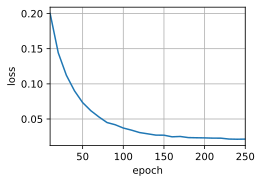

In [8]:
embed_size, num_hiddens, num_layers, dropout = 32, 32, 2, 0.1
batch_size, num_steps = 64, 10
lr, num_epochs, device = 0.005, 250, d2l.try_gpu()

train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)
encoder = d2l.Seq2SeqEncoder(
    len(src_vocab), embed_size, num_hiddens, num_layers, dropout)
decoder = Seq2SeqAttentionDecoder(
    len(tgt_vocab), embed_size, num_hiddens, num_layers, dropout)
net = d2l.EncoderDecoder(encoder, decoder)
d2l.train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

In [9]:
engs = ['go .', "i lost .", 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
for eng, fra in zip(engs, fras):
    translation, dec_attention_weight_seq = d2l.predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device, True)
    print(f'{eng} => {translation}, ',
          f'bleu {d2l.bleu(translation, fra, k=2):.3f}')

go . => va !,  bleu 1.000
i lost . => j'ai perdu .,  bleu 1.000
he's calm . => il est mouillé .,  bleu 0.658
i'm home . => je suis chez moi .,  bleu 1.000


In [10]:
attention_weights = torch.cat([step[0][0][0] for step in dec_attention_weight_seq], 0).reshape((
    1, 1, -1, num_steps))

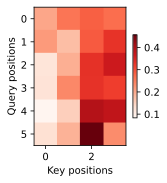

In [11]:
# 加上一个包含序列结束词元
d2l.show_heatmaps(
    attention_weights[:, :, :, :len(engs[-1].split()) + 1].cpu(),
    xlabel='Key positions', ylabel='Query positions')